<a href="https://colab.research.google.com/github/Anakad1/bootcampgenai/blob/main/dailyw2d4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd  # Make sure pandas is imported
import matplotlib.pyplot as plt



In [8]:
from google.colab import files



In [9]:
# Upload the file
uploaded = files.upload()

# Get the filename from the uploaded dictionary
filename = list(uploaded.keys())[0]

# Load the data into a pandas DataFrame called 'df'
df = pd.read_csv(filename)

Saving happy2015.csv to happy2015 (2).csv


In [10]:
print("Aperçu des données :")
print(df.head())
print("\nInformations sur les données :")
print(df.info())
print("\nValeurs manquantes :")
print(df.isnull().sum())

Aperçu des données :
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                   0.94143  0.66557                        0.41978   
1                   0.94784  0.62877                        0.14145   
2                   0.8746

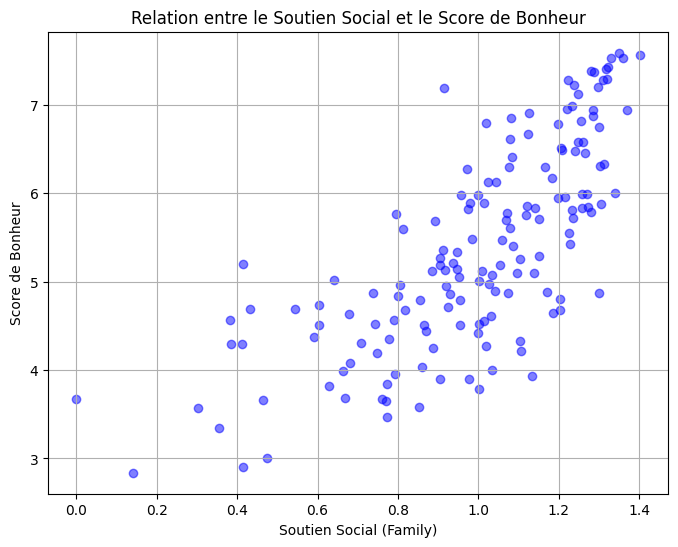

In [11]:
# 3 Analyse de la relation entre le soutien social et le bonheur
plt.figure(figsize=(8, 6))
plt.scatter(df["Family"], df["Happiness Score"], alpha=0.5, color='blue')
plt.xlabel("Soutien Social (Family)")
plt.ylabel("Score de Bonheur")
plt.title("Relation entre le Soutien Social et le Score de Bonheur")
plt.grid(True)
plt.show()

<ipython-input-12-acc2b2cfc3e5>:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(regional_data["Region"], rotation=45, ha='right')


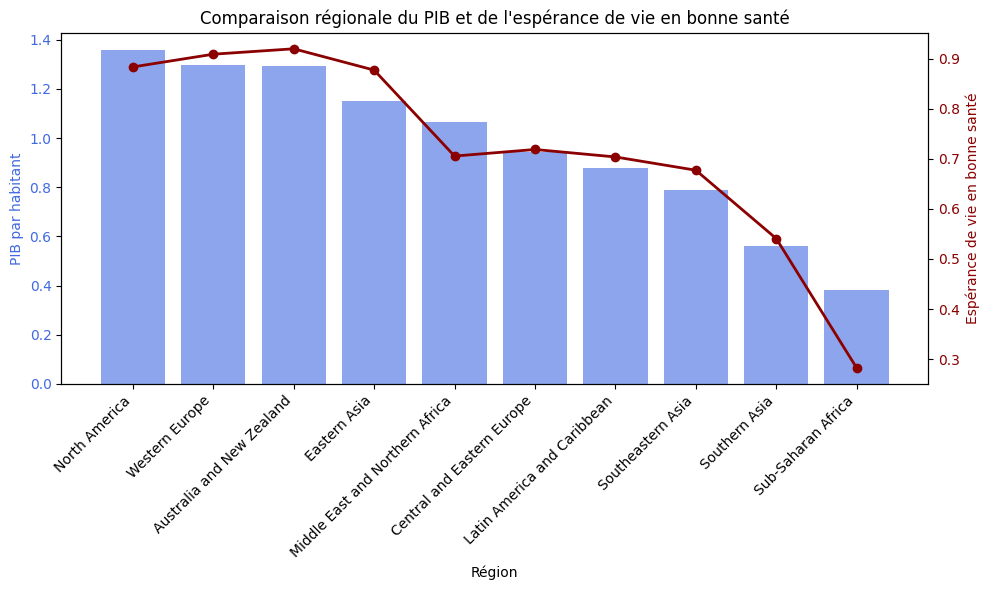

In [12]:
# 4. Comparaison régionale du PIB et de la santé
regional_data = df.groupby("Region").agg({"Economy (GDP per Capita)": "mean", "Health (Life Expectancy)": "mean"}).reset_index()
regional_data = regional_data.sort_values(by="Economy (GDP per Capita)", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(regional_data["Region"], regional_data["Economy (GDP per Capita)"], color='royalblue', alpha=0.6, label="PIB par habitant")
ax1.set_xlabel("Région")
ax1.set_ylabel("PIB par habitant", color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(regional_data["Region"], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(regional_data["Region"], regional_data["Health (Life Expectancy)"], color='darkred', marker='o', linestyle='-', linewidth=2, label="Espérance de vie")
ax2.set_ylabel("Espérance de vie en bonne santé", color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title("Comparaison régionale du PIB et de l'espérance de vie en bonne santé")
fig.tight_layout()
plt.show()